**Preliminari**

In [42]:
import sys
import os
from dotenv import load_dotenv
from pathlib import Path

from model_utils import create_label_to_id_map, labels_to_bits, bits_to_labels, NAN_VALUE, get_multiple_choice_fields, get_binary_classification_fields, get_classification_fields

# if notebook is in PRIN/notebooks, parent() is PRIN
#project_root = Path.cwd().resolve().parent
#sys.path.insert(0, str(project_root))
#print("Added to sys.path:", project_root)

import json
#from utils.schema_json import ReportData, AnnotatedReport
import time
from IPython.display import clear_output

from huggingface_hub import login

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from transformers import AutoTokenizer, DefaultDataCollator
from datasets import load_dataset, Dataset, DatasetDict

from constants import AnnotatedReport, Annotations

from classifiers import ReportExtractor
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from ast import literal_eval
import loop
import seaborn as sns
import matplotlib.pyplot as plt
from pprint import pprint
import math

In [3]:
plt.style.use('ggplot')

**Huggingface login**

**Parametri**

In [69]:
# Parameters
TRAIN_FILE_NAME = "train_split.csv"
VALIDATION_FILE_NAME = "validation_split.csv"
TEST_FILE_NAME = "test_split.csv"

**Load data**

In [70]:
# Carichiamo i nostri file csv
file_names = {
    'train': TRAIN_FILE_NAME,
    'validation': VALIDATION_FILE_NAME,
    'test': TEST_FILE_NAME  
}

paths = {
    split: Path('../data/' + file_name) for split, file_name in file_names.items()
}

data = dict()
for split, path in paths.items():
    data[split] = pd.read_csv(path)

train_data, validation_data, test_data = data['train'], data['validation'], data['test']
total_data = pd.concat([train_data, validation_data, test_data], ignore_index=True)

print(f"{len(train_data) = }")
print(f"{len(validation_data) = }")
print(f"{len(test_data) = }")

len(train_data) = 175
len(validation_data) = 43
len(test_data) = 57


In [71]:
mc_fields = get_multiple_choice_fields(Annotations)
cl_fields = get_classification_fields(Annotations)
bc_fields = get_binary_classification_fields(Annotations)
for field in train_data.columns:
    if field not in mc_fields + cl_fields + bc_fields:
        print(f"Field '{field}' not in any known annotation fields.")

Field 'report_text' not in any known annotation fields.
Field 'profile' not in any known annotation fields.
Field 'ore_inizio' not in any known annotation fields.
Field 'ore_fine' not in any known annotation fields.
Field 'spessore_parietale' not in any known annotation fields.
Field 'estensione_cranio_caudale' not in any known annotation fields.
Field 'distanza_oai' not in any known annotation fields.
Field 'numero_linfonodi_non_conosciuto' not in any known annotation fields.
Field 'linfonodi_sospetti' not in any known annotation fields.
Field 'numero_depositi' not in any known annotation fields.
Field 'split' not in any known annotation fields.


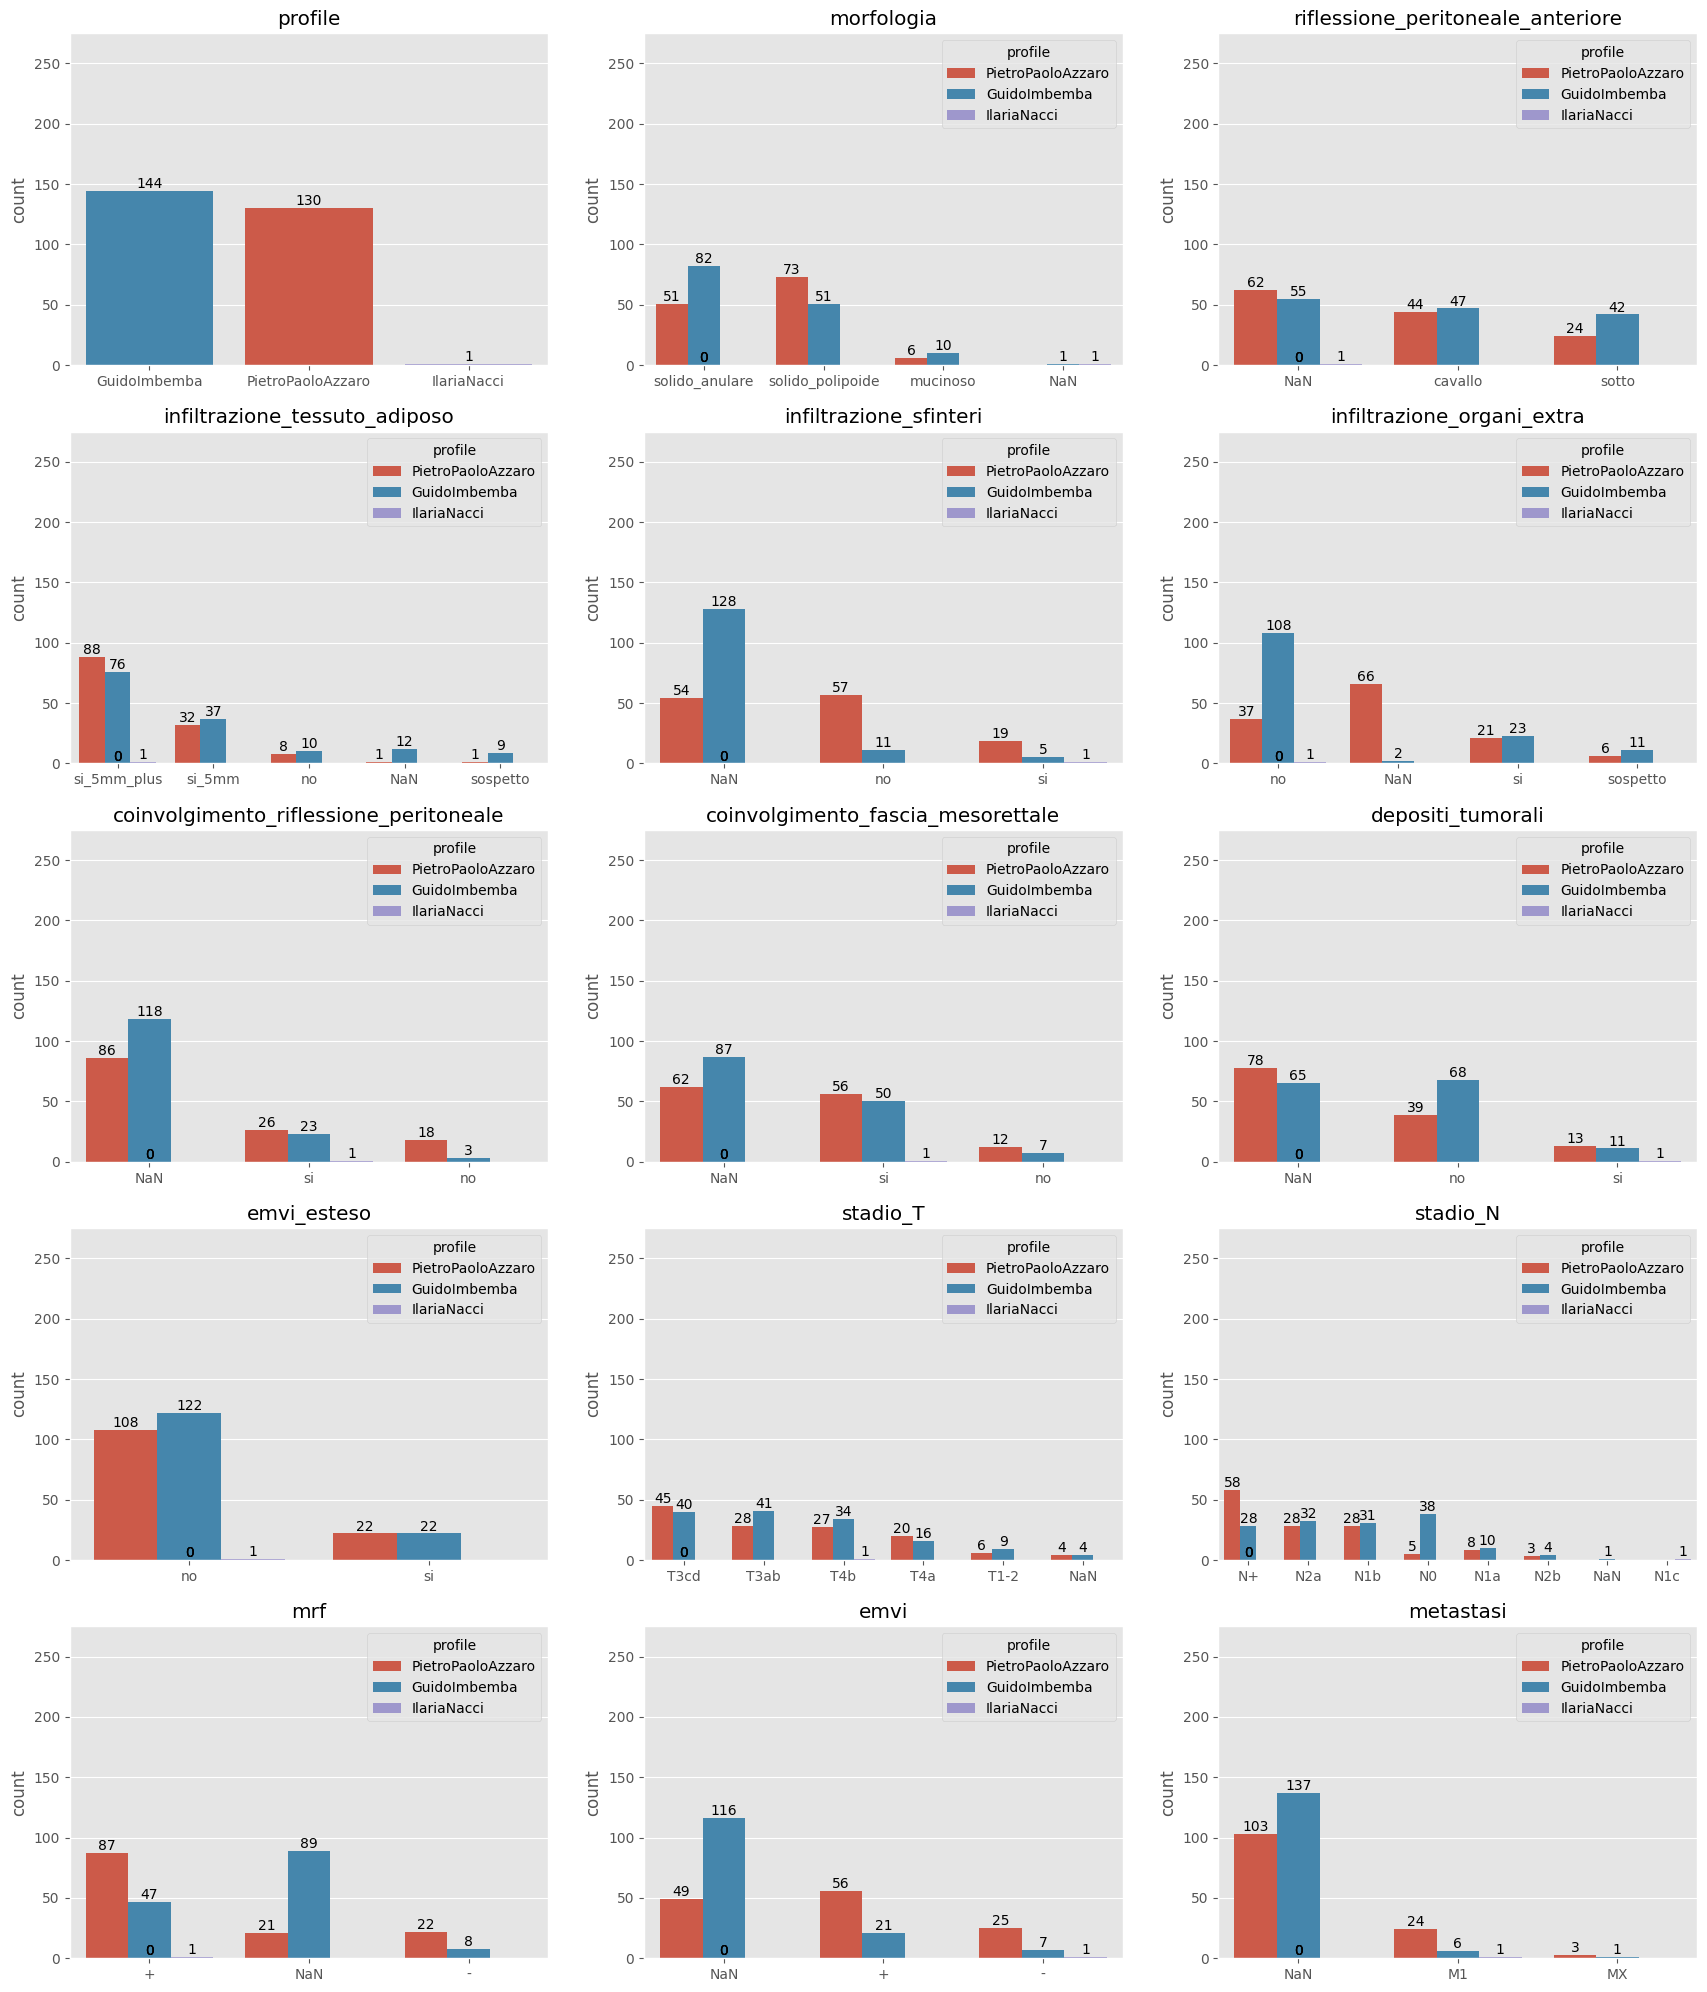

In [75]:
fields = ['profile'] + cl_fields
n_cols = 3
n_rows = math.ceil(len(fields) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 5*n_rows))
axes = axes.reshape(n_rows, n_cols)

df = []
for i, field in enumerate(fields):
    # PLot counts
    r = i // n_cols
    c = i % n_cols
    ax = axes[r, c]
    sns.countplot(x=field, data=total_data.fillna('NaN'), ax=ax, order=total_data.fillna('NaN')[field].value_counts().index, hue='profile')
    ax.set_title(field)
    ax.set_xlabel("")
    ax.set_ylim(0, total_data.shape[0])
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

for idx in range(len(fields), n_rows*n_cols):
    r = idx // n_cols
    c = idx % n_cols
    axes[r, c].axis("off")

plt.show()

Si osserva che la quantità di eferti annotati dai due annotatori (Guido e Pietropaolo) è simile, con un numero leggermente meggiore per Guido. Per questo, ci aspettiamo che anche per gli altri campi la distribuzione sia simile. Questo non accade per i seguenti campi:
- morfologia (solido anulare e solido polipoide)
- infiltrazione sfinteri
- infiltrazione organi extra
- coinvolgimento riflessione peritoneale
- coinvolgimento fascia mesorettale
- stadio N (N+ e N0)
- mrf
- emvi
- metastasi

Analizziamo ora solo i report annotati da Guido

modifiche da apportare:
- aggreghiamo MX a NaN
- potremmo aggregare T4a con T4b
- si potrebbe aggregare lo stadio N in N+ e N0
- per MRF si potrebbe aggregare "-" con NaN
- aggreghiamo mucinoso con NaN e lo facciamo diventare altro
- in infiltrazione organi extra aggreghiamo no con NaN e si con sospetto
- coinvolgimento fascia mesorettale, aggreghiamo no con NaN
- coinvolgimento riflessione peritoneale: aggreghiamo no cpn nan

In [78]:
# Parameters
TRAIN_FILE_NAME = "train_split_guido.csv"
VALIDATION_FILE_NAME = "validation_split_guido.csv"
TEST_FILE_NAME = "test_split_guido.csv"

In [82]:
# Carichiamo i nostri file csv
file_names = {
    'train': TRAIN_FILE_NAME,
    'validation': VALIDATION_FILE_NAME,
    'test': TEST_FILE_NAME  
}

paths = {
    split: Path('../data/' + file_name) for split, file_name in file_names.items()
}

data = dict()
for split, path in paths.items():
    data[split] = pd.read_csv(path)

train_data, validation_data, test_data = data['train'], data['validation'], data['test']
total_data = pd.concat([train_data, validation_data, test_data], ignore_index=True)

print(f"{len(train_data) = }")
print(f"{len(validation_data) = }")
print(f"{len(test_data) = }")

len(train_data) = 116
len(validation_data) = 28
len(test_data) = 28


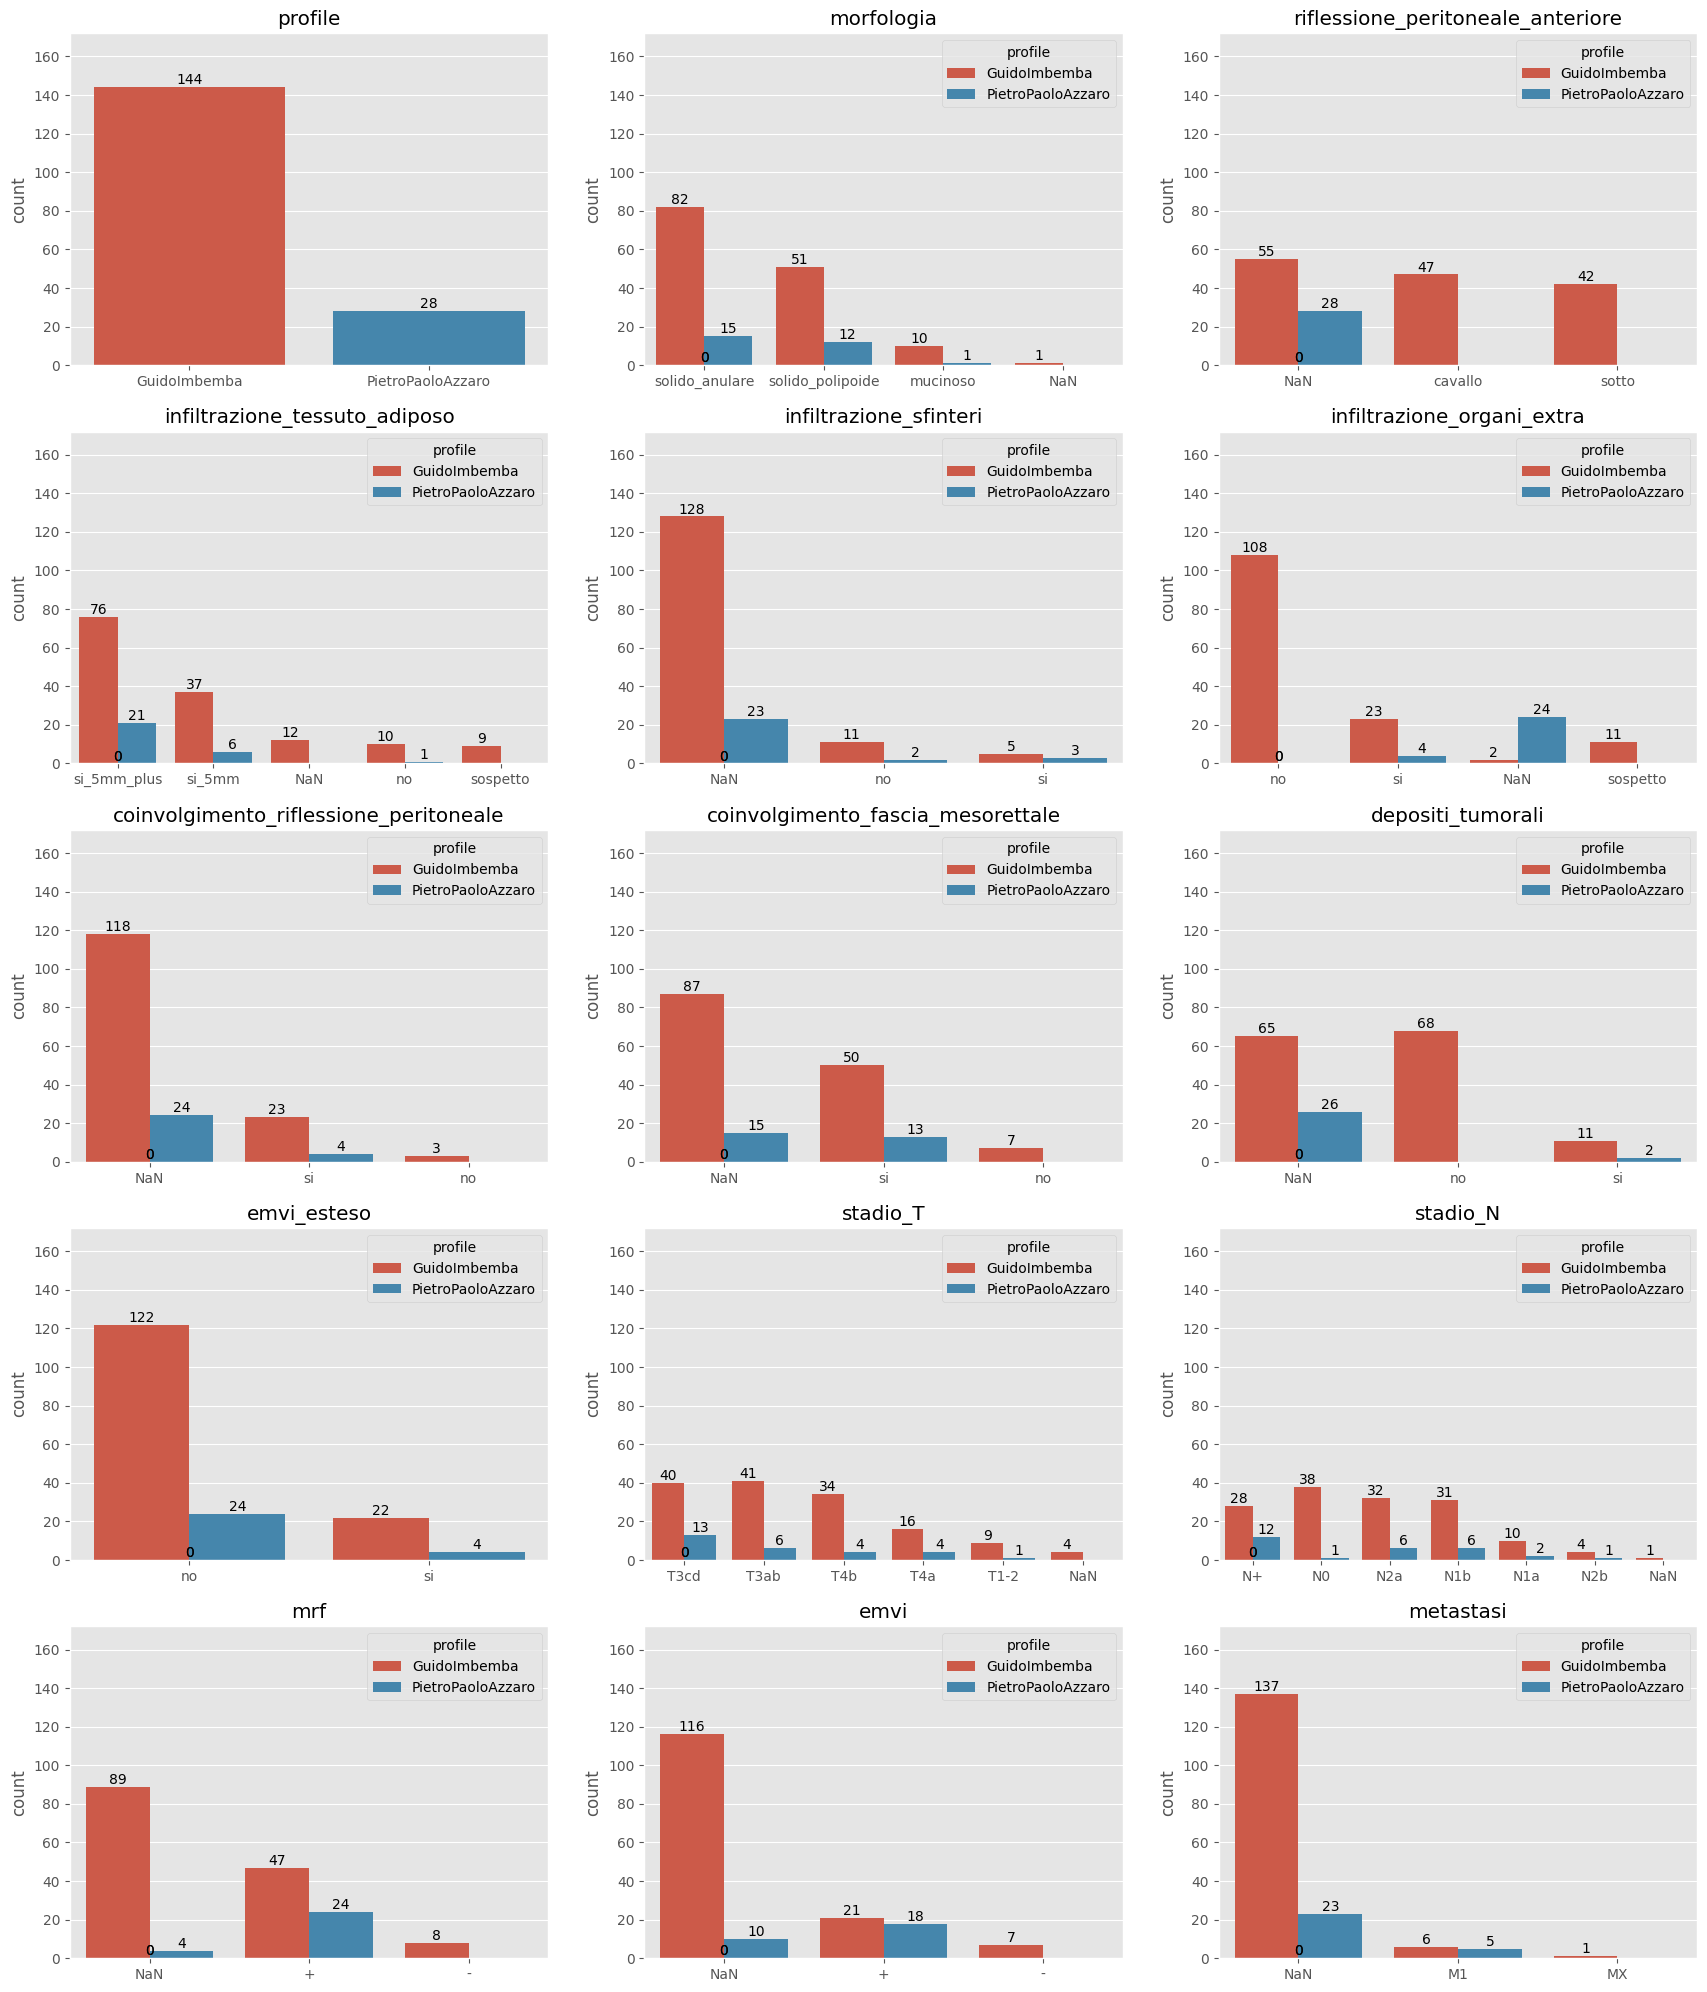

In [85]:
fields = ['profile'] + cl_fields
n_cols = 3
n_rows = math.ceil(len(fields) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 5*n_rows))
axes = axes.reshape(n_rows, n_cols)

df = []
for i, field in enumerate(fields):
    # PLot counts
    r = i // n_cols
    c = i % n_cols
    ax = axes[r, c]
    sns.countplot(x=field, data=total_data.fillna('NaN'), ax=ax, order=total_data.fillna('NaN')[field].value_counts().index, hue='profile')
    ax.set_title(field)
    ax.set_xlabel("")
    ax.set_ylim(0, total_data.shape[0])
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

for idx in range(len(fields), n_rows*n_cols):
    r = idx // n_cols
    c = idx % n_cols
    axes[r, c].axis("off")

plt.show()

In [36]:
annotated_reports: dict[str, list[AnnotatedReport]] = {split: [] for split in file_names.keys()}
for split in data:
    df = data[split].fillna(NAN_VALUE)
    for _, row in df.iterrows():
        annotations_dict = dict()
        for field in Annotations.model_fields.keys():
            v = row[field]
            if v == NAN_VALUE:
                v = None
            if field in mc_fields:
                v = literal_eval(v)
            annotations_dict[field] = v
        annotated_reports[split].append(AnnotatedReport(report_text=row['report_text'], report_data=annotations_dict))

In [ ]:
df = pd.read_csv(paths['train'])

In [65]:
base_dir = Path.cwd().parent

In [67]:
df = pd.read_csv(base_dir / 'data' / 'tumoreprimitivo_clean.csv')

In [68]:
df

,id,profile,discrepanze_rilevate,motivazioni_discrepanze,radiologist,patient_id,sesso,data_nascita,interpretazioni,report_text,...,distanza_minima_fascia_ore,linfonodi_sospetti,numero_linfonodi_non_conosciuto,sedi_locoregionali,sedi_non_locoregionali,depositi_tumorali,numero_depositi,emvi_esteso,status,sedi_linfonodi
0,422,PietroPaoloAzzaro,['nessuna'],nessuna,BRIZI DOTT. MARIA GABRIELLA,40165425,M,1938-08-27,NaN,RM ADDOME INFERIORE (S/C MDC)\nINDICAZIONE ALL...,...,NaN,0.0,True,"['mesorettali', 'rettali_superiori']",[],NaN,0.0,si,incomplete,"['mesorettali', 'rettali_superiori']"
1,421,PietroPaoloAzzaro,['nessuna'],nessuna,BARBARO PROF. BRUNELLA,32744039,M,1930-04-22,NaN,RM ADDOME INFERIORE L'ESAME STATO ESEGUITO MED...,...,NaN,4.0,False,"['mesorettali', 'otturatori']",[],NaN,0.0,si,incomplete,"['mesorettali', 'otturatori']"
2,420,PietroPaoloAzzaro,['nessuna'],nessuna,BARBARO PROF. BRUNELLA,14641435,M,1944-03-11,NaN,TC TOTAL BODY (TORACE + ADDOME COMPLETO) SENZ ...,...,NaN,0.0,True,['mesorettali'],[],NaN,0.0,no,incomplete,['mesorettali']
3,419,PietroPaoloAzzaro,['nessuna'],nessuna,BARBARO PROF. BRUNELLA,27394709,F,1960-01-19,NaN,RM PELVI FEMMINILE (CON MDC) \n \nESAME ES...,...,NaN,0.0,True,['mesorettali'],[],NaN,0.0,no,incomplete,['mesorettali']
4,417,PietroPaoloAzzaro,['nessuna'],nessuna,NaN,27473289,F,1934-03-30,NaN,RM PELVI (CON MDC)\n\n\nINDAGINE ESEGUITA MED...,...,NaN,4.0,False,"['rettali_superiori', 'mesorettali']",[],NaN,0.0,no,incomplete,"['mesorettali', 'rettali_superiori']"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270,52,GuidoImbemba,['nessuna'],nessuna,Barbaro Brunella,947754,F,1942-08-13,"vanno bene sfinteri? m1?\nNo, devi mettere Sfi...",IN CORRISPONDENZA DELLA PARETE POSTERO LATERAL...,...,NaN,1.0,False,['inguinali_sotto_dentata'],[],si,1.0,si,complete,['altro']
271,51,GuidoImbemba,['nessuna'],nessuna,De Gaetano Anna Maria,627893,M,1970-12-20,"Per i linfonodi sospetti dovevi inserire ""nume...",SI CONFERMA LA PRESENZA IN CORRISPONDENZA DEL ...,...,NaN,0.0,True,"['mesorettali', 'rettali_superiori']",[],si,1.0,no,complete,"['mesorettali', 'rettali_superiori']"
272,47,GuidoImbemba,['nessuna'],nessuna,Manfredi Riccardo,537381,F,1958-06-05,"metto mucinoso o solido-polipide?\n\nNo, non è...",SI DOCUMENTA UN ISPESSIMENTO FOCALE DELLA PARE...,...,NaN,0.0,False,[],[],no,0.0,no,complete,[]
273,46,GuidoImbemba,['nessuna'],nessuna,Guerrieri Daniele,236893,F,1937-10-08,NaN,"NEL RETTO MEDIO, A CIRCA 7 CM DAL MARGINE ANAL...",...,NaN,0.0,True,"['mesorettali', 'sacrali', 'otturatori', 'rett...",[],no,0.0,no,complete,"['altro', 'mesorettali', 'rettali_superiori', ..."
